# Gaussian Sampling inside an ellipse using PDLMC

## Target distribution and support

The reference distribution is

$$
\pi = \mathcal{N}(m, I_2),
\qquad
m = \begin{pmatrix} 2 \\ 2 \end{pmatrix}.
$$

Its density is

$$
\pi(x) = \frac{1}{2\pi}
\exp\left(-\frac{1}{2}\|x-m\|_2^2\right),
\qquad x \in \mathbb{R}^2.
$$

The constraint set is the ellipse

$$
C = \left\{
x \in \mathbb{R}^2 :
\left(\frac{x_1}{0.5}\right)^2
+
\left(\frac{x_2}{2}\right)^2
\le 1
\right\}.
$$

The exactly truncated target has density

$$
\pi_C(x)
=
\frac{\pi(x)\,\mathbf{1}_C(x)}
{\int_C \pi(u)\,du}.
$$


## Constrained sampling formulation

Let $\pi=\mathcal{N}((2,2)^\top,I_2)$ and define

$$
r(x)=\left(\frac{x_1}{0.5}\right)^2+\left(\frac{x_2}{2}\right)^2,
\qquad
g_\epsilon(x)=[r(x)-1]_+-\epsilon,
$$

where $[z]_+=\max(0,z)$. Our instance of $(P_I)$ is

$$
\min_{\mu\in\mathcal{P}_2(\mathbb{R}^2)}
\mathrm{KL}(\mu\|\pi)
\quad\text{subject to}\quad
\mathbb{E}_\mu[g_\epsilon(X)]\le0.
$$

There is one inequality constraint and no equality constraints.

For $\epsilon=0$, the constraint enforces support inside the ellipse
$r(x)\le1$, and the solution is the truncated Gaussian. We use
$\epsilon=10^{-3}$ to allow a small expected violation and permit
strict feasibility; the resulting target may have mass outside the ellipse.

PD-LMC uses the potential

$$
U(x,\lambda)=\frac12\|x-(2,2)^\top\|_2^2+\lambda g_\epsilon(x),
\qquad \lambda\ge0.
$$


### Here we'll compare the performance of PD-LMC with the exact truncated Gaussian samples obtained by simpling rejecting samples outside the constraint set.

## Imports

In [2]:
import torch
import matplotlib.pyplot as plt
from functools import partial

from constrained_sampling.targets import (
    potential_f,
    constraint_r,
    constraint_g,
)
from constrained_sampling.samplers import (
    pdlmc_chain,
    rejection_sampling,
)

## Configs

In [3]:
torch.set_default_dtype(torch.float64)

seed = 42
center = torch.tensor([2.0, 2.0])
a, b = 0.5, 2.0
epsilon = 1e-3

eta = 5e-4
n_steps = 600_000
burn_in = 300_000
n_reference = 10_000

x0 = torch.zeros(2)
lam0 = torch.tensor(0.0)

f = partial(potential_f, center=center)
r = partial(constraint_r, a=a, b=b)

def g(x):
    return torch.relu(r(x) - 1.0) - epsilon

## Selection baseline

In [4]:
torch.manual_seed(seed)

reference_samples, acceptance_rate = rejection_sampling(
    num_samples=n_reference,
    center=center,
    constraint_r=r,
)

reference_mean = reference_samples.mean(dim=0)

print(f"Acceptance rate: {acceptance_rate}")
print("Reference mean:", reference_mean.tolist())

Acceptance rate: 0.020806
Reference mean: [0.10129002462168626, 1.0196959548869622]


## Sampling with PD-LMC

In [5]:
torch.manual_seed(seed + 1)

x_chain, lam_chain = pdlmc_chain(
    x0=x0,
    lam0=lam0,
    eta=eta,
    potential_f=f,
    constraint_g=g,
    n_steps=n_steps,
)

samples = x_chain[burn_in + 1:]
sample_mean = samples.mean(dim=0)

print("PD-LMC mean:", sample_mean.tolist())
print(f"Average violation: {torch.relu(r(samples) - 1).mean().item()}")
print(f"Outside fraction: {(r(samples) > 1).double().mean().item()}")

PD-LMC mean: [0.11231425469426919, 1.053280876734178]
Average violation: 0.015113638784378118
Outside fraction: 0.13089666666666666


## Comparison

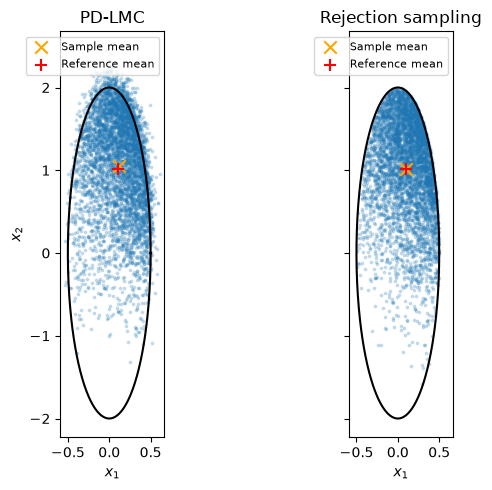

In [6]:
theta = torch.linspace(0, 2 * torch.pi, 400)
boundary = torch.stack((a * theta.cos(), b * theta.sin()), dim=1)

fig, axes = plt.subplots(1, 2, figsize=(7, 5), sharex=True, sharey=True)

for ax, points, title in zip(
    axes,
    [samples, reference_samples],
    ["PD-LMC", "Rejection sampling"],
):
    indices = torch.linspace(0, len(points) - 1, 5_000).long()
    shown = points[indices].detach().cpu()
    mean = points.mean(dim=0).detach().cpu()

    ax.scatter(shown[:, 0], shown[:, 1], s=3, alpha=0.2)
    ax.plot(boundary[:, 0], boundary[:, 1], color="black")
    ax.scatter(*mean.tolist(), marker="x", color="orange",
               s=80, label="Sample mean")
    ax.scatter(*reference_mean.tolist(), marker="+", color="red",
               s=80, label="Reference mean")
    ax.set(title=title, xlabel="$x_1$")
    ax.set_aspect("equal")
    ax.legend(fontsize=8)

axes[0].set_ylabel("$x_2$")
plt.tight_layout()
plt.show()

## Now we try the same experiment but with the support being a square

To do so we replace the ellipse with the square $[-1,1]^2$ by defining

$$
r(x)=\max(|x_1|,|x_2|).
$$

Rejection sampling accepts points with $r(x)\leq1$. PD-LMC uses
$g(x)=(r(x)-1)_+-\varepsilon$ to enforce the relaxed constraint
$\mathbb{E}_\mu[(r(X)-1)_+]\leq\varepsilon$.

In [7]:
half_width = 1.0

def r_square(x):
    return x.abs().amax(dim=-1) / half_width

def g_square(x):
    return torch.relu(r_square(x) - 1.0) - epsilon

In [8]:
torch.manual_seed(seed)

square_reference, square_acceptance = rejection_sampling(
    num_samples=n_reference,
    center=center,
    constraint_r=r_square,
)

square_reference_mean = square_reference.mean(dim=0)

print(f"Acceptance rate: {square_acceptance}")
print("Reference mean:", square_reference_mean.tolist())

Acceptance rate: 0.024666
Reference mean: [0.4906507548422367, 0.489824916472583]


In [9]:
torch.manual_seed(seed + 1)

square_x_chain, square_lam_chain = pdlmc_chain(
    x0=x0,
    lam0=lam0,
    eta=eta,
    potential_f=f,
    constraint_g=g_square,
    n_steps=n_steps,
)

square_samples = square_x_chain[burn_in + 1:]
square_mean = square_samples.mean(dim=0)

print("PD-LMC mean:", square_mean.tolist())
print(
    f"Average violation: "
    f"{torch.relu(r_square(square_samples) - 1).mean().item()}"
)
print(
    f"Outside fraction: "
    f"{(r_square(square_samples) > 1).double().mean().item()}"
)

PD-LMC mean: [0.5624474940412464, 0.5560351924374323]
Average violation: 0.019232293531582574
Outside fraction: 0.21891


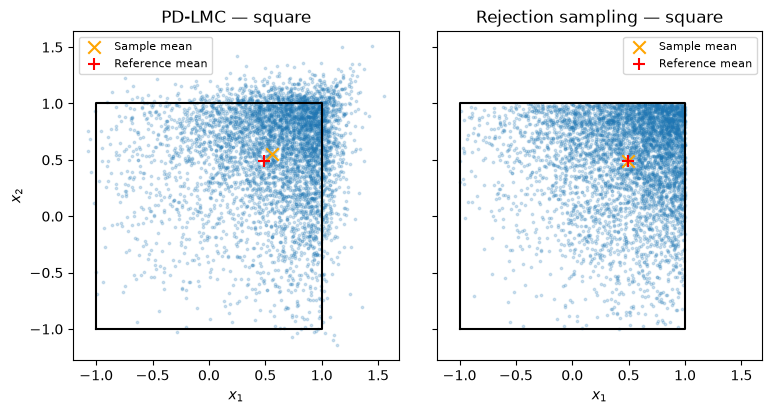

In [10]:
boundary = half_width * torch.tensor([
    [-1, -1], [1, -1], [1, 1], [-1, 1], [-1, -1],
])

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

for ax, points, title in zip(
    axes,
    [square_samples, square_reference],
    ["PD-LMC — square", "Rejection sampling — square"],
):
    indices = torch.linspace(0, len(points) - 1, 5_000).long()
    shown = points[indices].detach().cpu()
    mean = points.mean(dim=0).detach().cpu()

    ax.scatter(shown[:, 0], shown[:, 1], s=3, alpha=0.2)
    ax.plot(boundary[:, 0], boundary[:, 1], color="black")
    ax.scatter(*mean.tolist(), marker="x", color="orange",
               s=80, label="Sample mean")
    ax.scatter(*square_reference_mean.tolist(), marker="+", color="red",
               s=80, label="Reference mean")
    ax.set(title=title, xlabel="$x_1$")
    ax.set_aspect("equal")
    ax.legend(fontsize=8)

axes[0].set_ylabel("$x_2$")
plt.tight_layout()
plt.show()